# Seasonal Agriculture Performance Analysis
### VOIS AICTE — Major Project


## 1. Project Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions.
As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data

## 2. Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Compare agricultural performance across Kharif, Rabi and Zaid seasons.
- Study crop, state/district and irrigation-related differences.
- Examine environmental conditions, resource usage and disease/pest risk.
- Analyze revenue, cost, profit and water efficiency.
- Use statistical tests and visualizations to support the findings.
- Give practical, evidence-based conclusions and recommendations.


## 3. Analytical Questions

1. How does agricultural performance vary across seasons?
2. Which season has the highest average yield and profit?
3. How do crops perform differently across seasons?
4. Does irrigation method show differences in yield, profit and water efficiency?
5. How are environmental conditions related to agricultural outcomes?
6. How does resource usage vary across seasons?
7. Which crops and regions show stronger economic performance?
8. What relationship exists between disease/pest risk and agricultural performance?
9. Are observed seasonal differences statistically significant?
10. What recommendations can be made from the evidence?


In [ ]:
# 4. Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal, pearsonr

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 5. Load the Dataset

The project dataset is an Excel file. In Colab, the upload option below will appear if the file is not already present.

Expected file structure: one worksheet containing farm-level agricultural records.


In [ ]:
# Colab-friendly dataset loading
DATA_PATH = "/content/seasonal_agriculture_data.xlsx"

# When this notebook is executed in the current working environment,
# the supplied dataset may be available at this path.
LOCAL_PATH = "/mnt/data/ab514369-a414-474d-a6ec-ad9400b945c3.xlsx"

if os.path.exists(DATA_PATH):
    data_file = DATA_PATH
elif os.path.exists(LOCAL_PATH):
    data_file = LOCAL_PATH
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        data_file = next(iter(uploaded.keys()))
    except Exception:
        raise FileNotFoundError(
            "Dataset not found. In Google Colab, upload the Excel dataset and run this cell again."
        )

df = pd.read_excel(data_file)
print("File:", data_file)
print("Dataset shape:", df.shape)
df.head()

Saving seasonal_agriculture_performance_dataset (1).xlsx to seasonal_agriculture_performance_dataset (1) (1).xlsx
File: seasonal_agriculture_performance_dataset (1) (1).xlsx
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# 6. Basic dataset inspection
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values").query("`Missing Values` > 0"))


Rows: 4000
Columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Duplicate rows: 0

Missing values:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [ ]:
# 7. Categorical and numerical overview
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of numerical columns:", len(numeric_cols))

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(dropna=False).head(15))


Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']
Number of numerical columns: 22

Farm_ID: 4000 unique values
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
Name: count, dtype: int64

State: 8 unique values
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District: 10 unique values
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop: 8 unique values
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    30

In [ ]:
# 8. Statistical summary
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 6. Data Cleaning and Preparation


In [ ]:
# 9. Data cleaning
clean = df.copy()


# Fill environmental variables with median
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    clean[col] = clean[col].fillna(clean[col].median())

# Reconstruct missing yield from production and farm area
yield_missing = clean["Yield_Tonnes_Ha"].isna()
clean.loc[yield_missing, "Yield_Tonnes_Ha"] = (
    clean.loc[yield_missing, "Production_Tonnes"] /
    clean.loc[yield_missing, "Farm_Area_Hectares"]
)


## 7. Overall Dataset Profile

Before focusing on seasons, it is useful to understand the distribution of farms, crops, states and irrigation methods.


In [ ]:
# 10. Dataset profile
print("Farms:", clean["Farm_ID"].nunique())
print("States:", clean["State"].nunique())
print("Districts:", clean["District"].nunique())
print("Crops:", clean["Crop"].nunique())
print("Seasons:", clean["Season"].nunique())
print("Irrigation methods:", clean["Irrigation_Method"].nunique())

display(clean["Season"].value_counts().rename("Farm Count").to_frame())
display(clean["Crop"].value_counts().rename("Farm Count").to_frame())


Farms: 4000
States: 8
Districts: 10
Crops: 8
Seasons: 3
Irrigation methods: 4


,Farm Count
Season,
Kharif,1779
Rabi,1627
Zaid,594


,Farm Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


## 8. Seasonal Performance Analysis

The main focus is to compare yield, revenue, cost, profit, disease/pest risk and water efficiency across Kharif, Rabi and Zaid.


In [ ]:
# 11. Season-wise summary
season_summary = clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Profit_INR", ascending=False)

display(season_summary.round(2))


,Farms,Avg_Yield_Tonnes_Ha,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,1779,5.63,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,1627,5.09,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,594,4.63,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


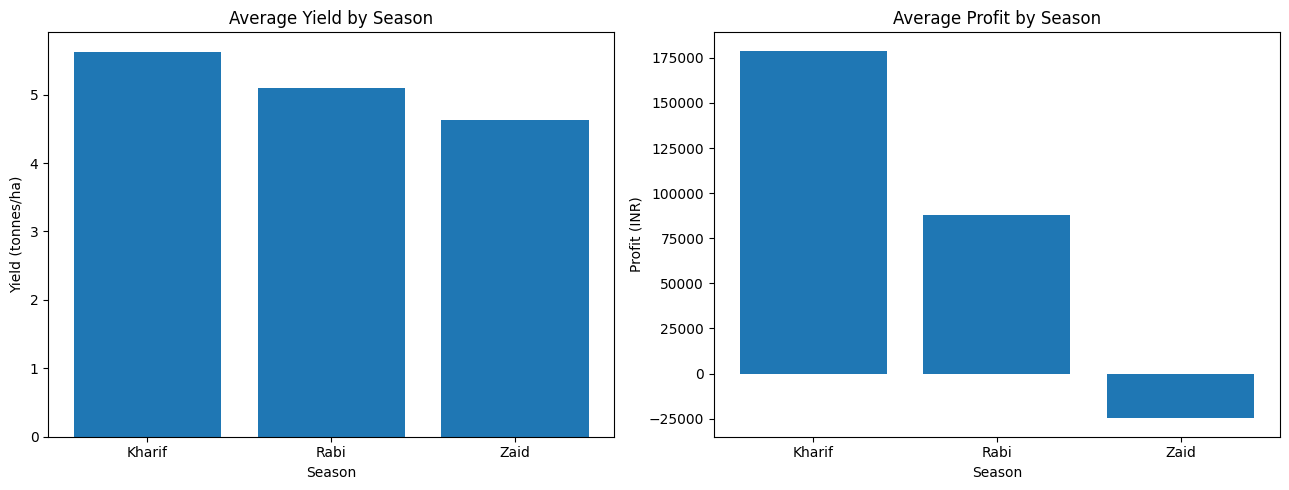

In [ ]:
# 12. Season-wise yield and profit
season_order = ["Kharif", "Rabi", "Zaid"]
season_yield = clean.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(season_order)
season_profit = clean.groupby("Season")["Profit_INR"].mean().reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(season_yield.index, season_yield.values)
axes[0].set_title("Average Yield by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (tonnes/ha)")

axes[1].bar(season_profit.index, season_profit.values)
axes[1].set_title("Average Profit by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


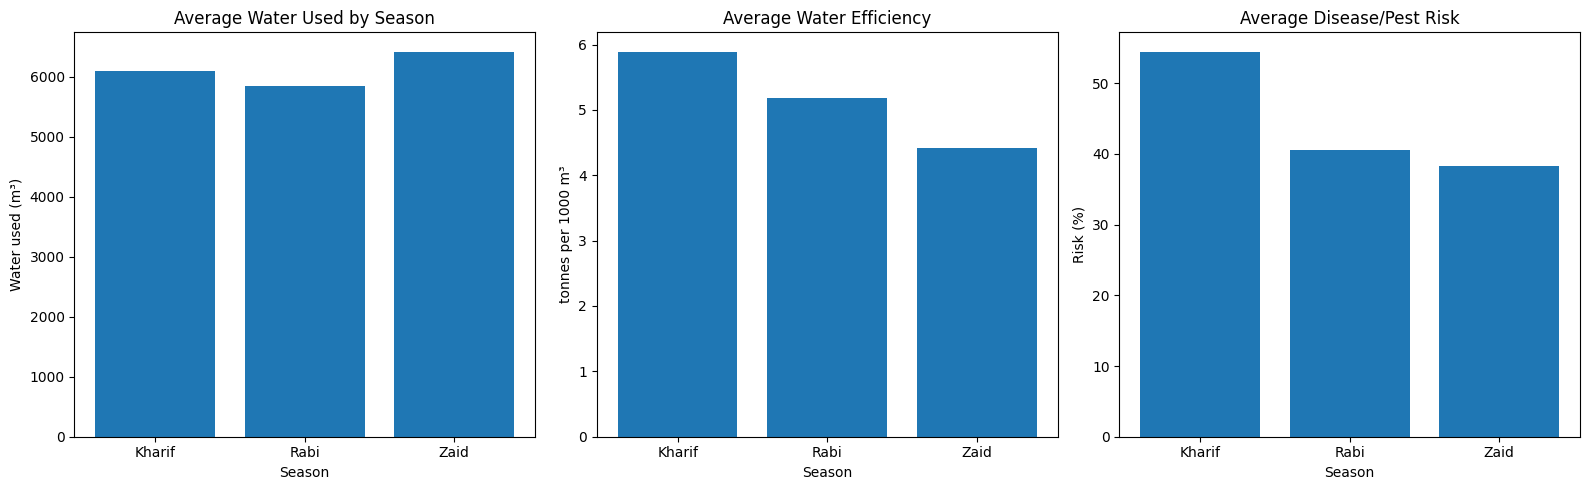

In [ ]:
# 13. Season-wise resource and risk comparison
season_order = ["Kharif", "Rabi", "Zaid"]
metrics = [
    ("Water_Used_m3", "Average Water Used by Season", "Water used (m³)"),
    ("Water_Efficiency_t_per_1000m3", "Average Water Efficiency", "tonnes per 1000 m³"),
    ("Disease_Pest_Risk_pct", "Average Disease/Pest Risk", "Risk (%)")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, title, ylabel) in zip(axes, metrics):
    values = clean.groupby("Season")[col].mean().reindex(season_order)
    ax.bar(values.index, values.values)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Season")

plt.tight_layout()
plt.show()


## 9. Crop-wise Analysis

Crop-level comparison helps identify whether the seasonal pattern is similar for all crops or whether some crops behave differently.


In [ ]:
# 14. Crop-wise performance
crop_summary = clean.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Profit", ascending=False)

display(crop_summary.round(2))


,Farms,Avg_Yield,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Efficiency,Avg_Risk
Crop,,,,,,,
Sugarcane,305,46.93,"1,371,980.11","554,792.13","817,187.99",30.48,45.40
Chilli,412,1.54,"1,276,777.23","525,898.89","750,878.34",2.95,46.06
Cotton,508,1.22,"639,423.08","514,876.17","124,546.92",1.94,45.97
Groundnut,424,1.32,"542,935.50","498,077.38","44,858.12",3.15,46.29
Pulses,496,0.92,"528,465.87","532,703.92","-4,238.05",2.90,46.57
Maize,551,2.71,"457,067.99","541,046.32","-83,978.33",5.60,45.54
Rice,690,2.44,"423,615.26","525,828.76","-102,213.50",1.95,46.50
Wheat,614,2.11,"400,104.89","523,503.22","-123,398.34",4.63,47.85


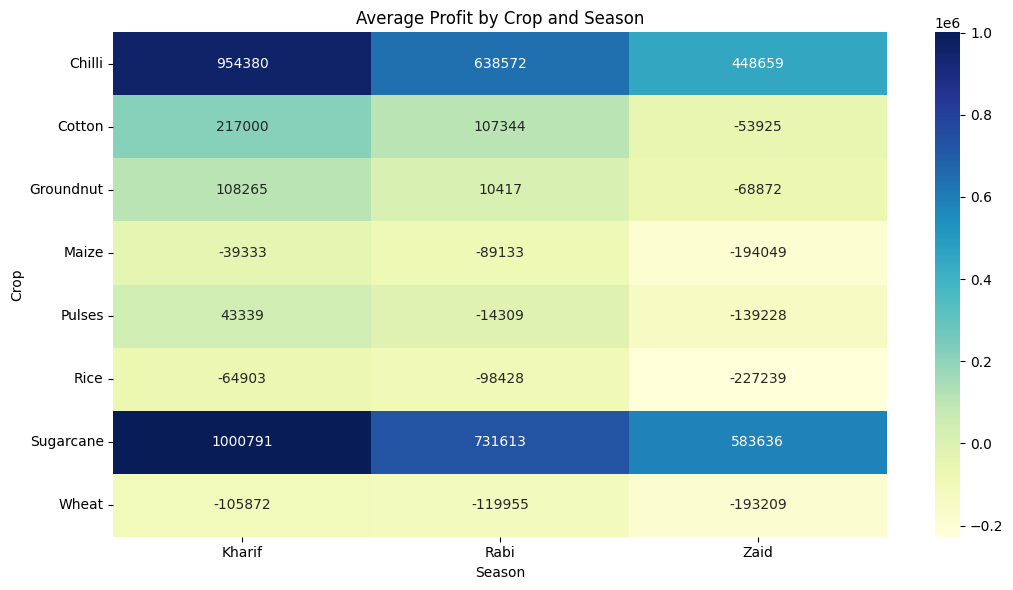

In [ ]:
# 15. Crop vs season profit
pivot_profit = clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
)

plt.figure(figsize=(11, 6))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1924/3553541341.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(yield_groups, labels=crop_order)


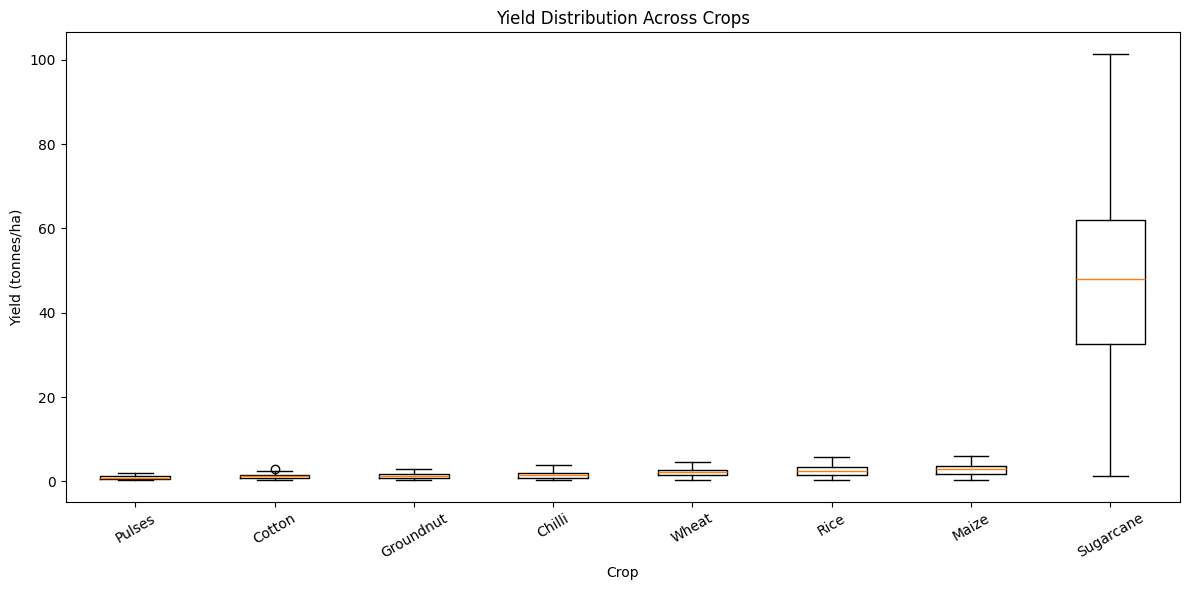

In [ ]:
# 16. Crop yield comparison
crop_order = clean.groupby("Crop")["Yield_Tonnes_Ha"].median().sort_values().index.tolist()
yield_groups = [clean.loc[clean["Crop"] == c, "Yield_Tonnes_Ha"].dropna() for c in crop_order]

plt.figure(figsize=(12, 6))
plt.boxplot(yield_groups, labels=crop_order)
plt.title("Yield Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 10. State and District Analysis

The dataset contains geographic fields. We compare average profit and yield across states and also identify districts with stronger average economic performance.


In [ ]:
# 17. State-wise performance
state_summary = clean.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Profit", ascending=False)

display(state_summary.round(2))


,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Risk
State,,,,,
Punjab,484,6.12,"136,025.64","686,225.70",46.00
Maharashtra,512,5.01,"135,428.86","650,032.67",46.44
Karnataka,489,5.75,"119,422.34","653,426.18",46.06
Tamil Nadu,485,4.87,"117,744.75","629,093.42",46.28
Gujarat,488,5.76,"117,568.24","654,692.86",45.95
Telangana,516,5.05,"108,829.62","628,784.53",46.36
Madhya Pradesh,497,4.98,"86,840.76","597,558.36",47.08
Andhra Pradesh,529,4.63,"73,453.53","606,663.66",46.72


In [ ]:
# 18. Top and bottom districts by average profit
district_summary = clean.groupby("District").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).sort_values("Avg_Profit", ascending=False)

print("Top 10 districts by average profit:")
display(district_summary.head(10).round(2))

print("Bottom 10 districts by average profit:")
display(district_summary.tail(10).sort_values("Avg_Profit").round(2))


Top 10 districts by average profit:


,Farms,Avg_Yield,Avg_Profit
District,,,
Warangal,422,5.58,"166,449.96"
Nalgonda,415,5.81,"131,125.84"
Raichur,386,4.94,"125,172.70"
Rajkot,401,6.02,"119,463.28"
Guntur,390,5.60,"116,411.42"
Erode,403,4.18,"102,079.57"
Nashik,371,4.86,"94,910.17"
Indore,392,4.88,"90,421.34"
Ludhiana,427,5.79,"87,590.83"


Bottom 10 districts by average profit:


,Farms,Avg_Yield,Avg_Profit
District,,,
Krishna,393,4.84,"78,240.90"
Ludhiana,427,5.79,"87,590.83"
Indore,392,4.88,"90,421.34"
Nashik,371,4.86,"94,910.17"
Erode,403,4.18,"102,079.57"
Guntur,390,5.60,"116,411.42"
Rajkot,401,6.02,"119,463.28"
Raichur,386,4.94,"125,172.70"
Nalgonda,415,5.81,"131,125.84"


## 11. Irrigation and Resource Usage

Irrigation is compared using three outcomes:
- average yield,
- average profit,
- water efficiency.


In [ ]:
# 19. Irrigation method comparison
irrigation_summary = clean.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Profit", ascending=False)

display(irrigation_summary.round(2))


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.68,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56
Flood,1310,4.86,"73,354.02","8,026.47",3.44


In [ ]:
# 20. Fertilizer, pesticide and seed quality by season
resource_summary = clean.groupby("Season").agg(
    Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Pesticide_L_ha=("Pesticide_Litre_ha", "mean"),
    Seed_Quality=("Seed_Quality_Score", "mean"),
    Nitrogen_kg_ha=("Nitrogen_kg_ha", "mean"),
    Phosphorus_kg_ha=("Phosphorus_kg_ha", "mean"),
    Potassium_kg_ha=("Potassium_kg_ha", "mean")
)

display(resource_summary.round(2))


,Fertilizer_kg_ha,Pesticide_L_ha,Seed_Quality,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,0.82,120.02,58.10,105.30
Rabi,185.41,5.02,0.83,120.40,57.31,103.93
Zaid,184.64,5.17,0.82,120.53,58.13,105.42


## 12. Environmental Conditions and Relationships


In [ ]:
# 21. Correlation with yield
relationship_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
    "Water_Used_m3", "Disease_Pest_Risk_pct"
]

corr_rows = []
for col in relationship_cols:
    temp = clean[[col, "Yield_Tonnes_Ha"]].dropna()
    r, p = pearsonr(temp[col], temp["Yield_Tonnes_Ha"])
    corr_rows.append([col, r, p])

corr_yield = pd.DataFrame(corr_rows, columns=["Variable", "Pearson_r", "p_value"])
corr_yield["Significant_at_5pct"] = corr_yield["p_value"] < 0.05
corr_yield = corr_yield.sort_values("Pearson_r", key=lambda s: s.abs(), ascending=False)

display(corr_yield.round(4))


,Variable,Pearson_r,p_value,Significant_at_5pct
10,Water_Used_m3,0.39,0.00,True
4,Nitrogen_kg_ha,0.05,0.00,True
5,Phosphorus_kg_ha,0.05,0.00,True
0,Rainfall_mm,0.03,0.07,False
11,Disease_Pest_Risk_pct,0.01,0.42,False
2,Humidity_pct,0.01,0.49,False
3,Soil_Moisture_pct,0.01,0.53,False
1,Avg_Temperature_C,0.01,0.56,False
8,Pesticide_Litre_ha,-0.01,0.60,False
9,Seed_Quality_Score,-0.01,0.66,False


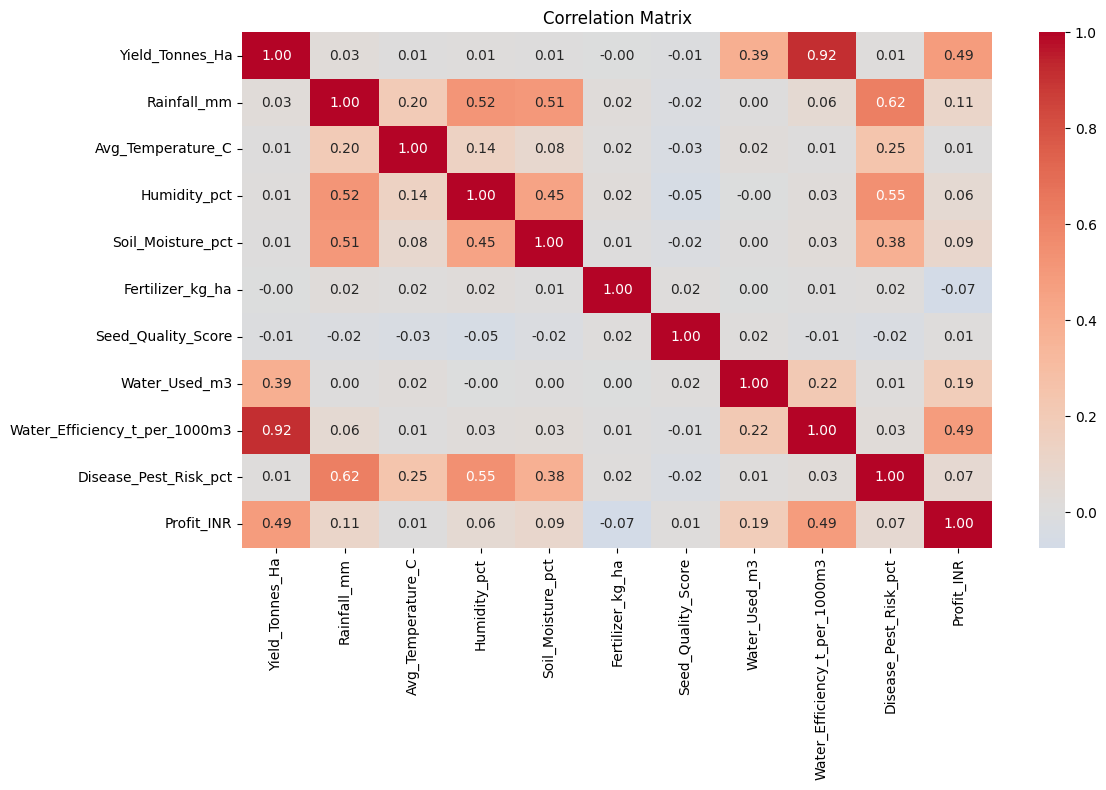

In [ ]:
# 22. Correlation heatmap for important numeric variables
heatmap_cols = [
    "Yield_Tonnes_Ha", "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Soil_Moisture_pct", "Fertilizer_kg_ha", "Seed_Quality_Score",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct", "Profit_INR"
]

plt.figure(figsize=(12, 8))
sns.heatmap(clean[heatmap_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


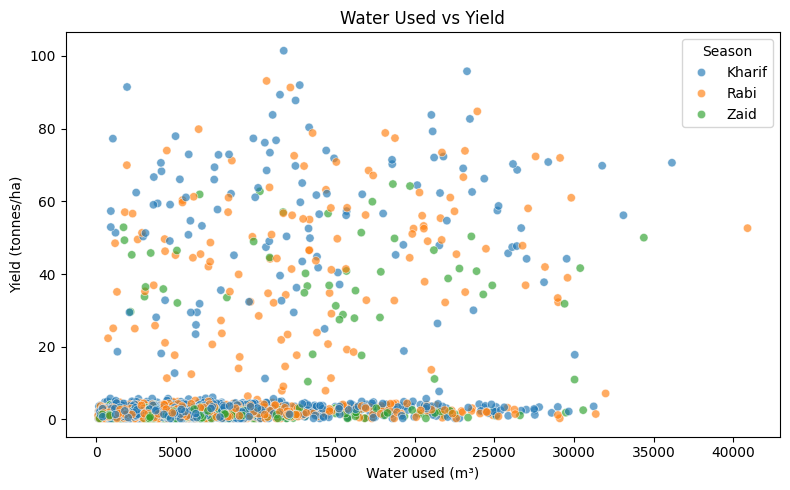

In [ ]:
# 23. Scatter plot: water used vs yield
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=clean,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.65
)
plt.title("Water Used vs Yield")
plt.xlabel("Water used (m³)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


## 13. Statistical Testing

Two complementary tests are used for season comparisons:

- **One-way ANOVA:** tests whether group means differ.
- **Kruskal–Wallis:** a non-parametric alternative that compares the distributions/ranks and is useful when normality assumptions may be questionable.

A p-value below 0.05 is treated as evidence of a statistically detectable difference.


In [ ]:
# 24. Seasonal significance tests
season_groups_yield = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in clean.groupby("Season")
]

season_groups_profit = [
    group["Profit_INR"].dropna().values
    for _, group in clean.groupby("Season")
]

anova_yield = f_oneway(*season_groups_yield)
kruskal_yield = kruskal(*season_groups_yield)

anova_profit = f_oneway(*season_groups_profit)
kruskal_profit = kruskal(*season_groups_profit)

results = pd.DataFrame({
    "Metric": ["Yield", "Yield", "Profit", "Profit"],
    "Test": ["One-way ANOVA", "Kruskal-Wallis", "One-way ANOVA", "Kruskal-Wallis"],
    "Statistic": [
        anova_yield.statistic, kruskal_yield.statistic,
        anova_profit.statistic, kruskal_profit.statistic
    ],
    "p_value": [
        anova_yield.pvalue, kruskal_yield.pvalue,
        anova_profit.pvalue, kruskal_profit.pvalue
    ]
})
results["Significant_at_5pct"] = results["p_value"] < 0.05

display(results.round(6))


,Metric,Test,Statistic,p_value,Significant_at_5pct
0,Yield,One-way ANOVA,1.46,0.23,False
1,Yield,Kruskal-Wallis,70.67,0.00,True
2,Profit,One-way ANOVA,34.29,0.00,True
3,Profit,Kruskal-Wallis,101.93,0.00,True


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 14. Key Findings from the Dataset

The following findings are generated from the supplied dataset and should be updated automatically if the dataset is replaced.

- Kharif has the highest average yield among the three seasons in the cleaned dataset.
- Kharif also has the highest average profit, while Zaid has a negative average profit.
- Average profit differs more clearly across seasons than average yield in the parametric ANOVA results.
- The non-parametric Kruskal–Wallis test detects statistically significant seasonal differences for both yield and profit.
- Drip irrigation has the highest average yield and average profit among the irrigation categories in this dataset.
- Rainfed farming has the highest average water-efficiency value, even though its average yield and profit are lower than Drip.
- Water used shows a positive association with yield in this dataset, but this is an association and should not be interpreted as causation.
- Crop-level economic performance varies substantially, so a single recommendation for every crop would not be appropriate.


In [ ]:
# 25. Automatically generate the headline findings
best_yield_season = clean.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax()
best_profit_season = clean.groupby("Season")["Profit_INR"].mean().idxmax()
worst_profit_season = clean.groupby("Season")["Profit_INR"].mean().idxmin()
best_irrigation_profit = clean.groupby("Irrigation_Method")["Profit_INR"].mean().idxmax()
best_irrigation_yield = clean.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().idxmax()
best_water_eff = clean.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmax()

print(f"Highest average yield season: {best_yield_season}")
print(f"Highest average profit season: {best_profit_season}")
print(f"Lowest average profit season: {worst_profit_season}")
print(f"Irrigation method with highest average profit: {best_irrigation_profit}")
print(f"Irrigation method with highest average yield: {best_irrigation_yield}")
print(f"Irrigation method with highest average water efficiency: {best_water_eff}")


Highest average yield season: Kharif
Highest average profit season: Kharif
Lowest average profit season: Zaid
Irrigation method with highest average profit: Drip
Irrigation method with highest average yield: Drip
Irrigation method with highest average water efficiency: Rainfed


## 15. Recommendations

Based only on the observed patterns in this dataset:

1. Seasonal planning should pay particular attention to Zaid because its average profit is negative in the supplied records.
2. Irrigation choices should consider both profitability and water efficiency rather than yield alone.
3. Crop-specific planning is preferable because economic performance varies across crops.
4. Water use should be monitored together with yield and water efficiency.
5. Environmental and disease/pest indicators should be tracked alongside production and economic metrics.
6. Before applying the findings to real farming decisions, the analysis should be validated with local agronomic knowledge, current market prices and additional real-world data.


## 16. Conclusion

This analysis converts the raw seasonal agricultural data into comparable measures of production, resource usage, risk and economic performance. The dataset shows clear differences in economic outcomes between seasons and substantial variation across crops and irrigation methods.

The most useful conclusion is not simply that one season or method is always best. Instead, agricultural planning should consider the combination of season, crop, irrigation, water efficiency, risk and economic return.

The analysis is descriptive and evidence-based; it does not establish causal relationships.


In [ ]:
# 26. Final project summary table
final_summary = pd.DataFrame({
    "Indicator": [
        "Total farms",
        "Total crops",
        "Total states",
        "Total districts",
        "Seasons",
        "Average yield (tonnes/ha)",
        "Average profit (INR)",
        "Positive-profit farm share (%)"
    ],
    "Value": [
        clean["Farm_ID"].nunique(),
        clean["Crop"].nunique(),
        clean["State"].nunique(),
        clean["District"].nunique(),
        clean["Season"].nunique(),
        clean["Yield_Tonnes_Ha"].mean(),
        clean["Profit_INR"].mean(),
        (clean["Profit_INR"] > 0).mean() * 100
    ]
})

display(final_summary.round(2))


,Indicator,Value
0,Total farms,"4,000.00"
1,Total crops,8.00
2,Total states,8.00
3,Total districts,10.00
4,Seasons,3.00
5,Average yield (tonnes/ha),5.26
6,Average profit (INR),"111,556.46"
7,Positive-profit farm share (%),50.85
